In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import scipy.stats as stats
import Levenshtein
from collections import Counter

In [2]:
all_validation_data = pd.read_csv('../data/datasets.csv',index_col=0)

In [6]:
all_validation_data.dataset.unique()

array(['VDJdb', 'VDJdb Sept. (New)', '1e6 TCR', 'TCRvdb', 'IMMREP25 Test',
       'Cross-Reactivity', 'NY-ESO', 'PTEAM', 'Minigene', 'T1D', 'MAGE',
       'Cov2', 'TIL1383I'], dtype=object)

In [8]:
mut = all_validation_data[all_validation_data.dataset.isin(['Cross-Reactivity', 'NY-ESO', 'PTEAM', 'Minigene', 'T1D', 'MAGE',
       'Cov2', 'TIL1383I'])]

In [30]:
mut[mut.TCR_name.str.startswith("SVAR")]

,dataset,TCR_name,peptide,label,HLA,TRA_CDR3,TRB_CDR3,cdr3_both
0,Cov2,SVAR-13,ALQPRTFLL,True,HLA-A*02:01,CVVNKEDRLMF,CASSDQNTGELFF,CVVNKEDRLMF_CASSDQNTGELFF
1,Cov2,SVAR-13,CLQPRTFLL,True,HLA-A*02:01,CVVNKEDRLMF,CASSDQNTGELFF,CVVNKEDRLMF_CASSDQNTGELFF
2,Cov2,SVAR-13,DLQPRTFLL,False,HLA-A*02:01,CVVNKEDRLMF,CASSDQNTGELFF,CVVNKEDRLMF_CASSDQNTGELFF
3,Cov2,SVAR-13,ELQPRTFLL,True,HLA-A*02:01,CVVNKEDRLMF,CASSDQNTGELFF,CVVNKEDRLMF_CASSDQNTGELFF
4,Cov2,SVAR-13,FLQPRTFLL,True,HLA-A*02:01,CVVNKEDRLMF,CASSDQNTGELFF,CVVNKEDRLMF_CASSDQNTGELFF
...,...,...,...,...,...,...,...,...
3905,Cov2,SVAR-92,YSQPRTFLL,False,HLA-A*02:01,CILIVGNYGQVFVF,CASSLIYSLSKEQYF,CILIVGNYGQVFVF_CASSLIYSLSKEQYF
3906,Cov2,SVAR-92,YTQPRTFLL,False,HLA-A*02:01,CILIVGNYGQVFVF,CASSLIYSLSKEQYF,CILIVGNYGQVFVF_CASSLIYSLSKEQYF
3907,Cov2,SVAR-92,YVQPRTFLL,False,HLA-A*02:01,CILIVGNYGQVFVF,CASSLIYSLSKEQYF,CILIVGNYGQVFVF_CASSLIYSLSKEQYF
3908,Cov2,SVAR-92,YWQPRTFLL,False,HLA-A*02:01,CILIVGNYGQVFVF,CASSLIYSLSKEQYF,CILIVGNYGQVFVF_CASSLIYSLSKEQYF


In [25]:
[x.replace(".fasta","") for x in os.listdir('../../../tcren/tcrpmhc_models_input_fastas') if x.replace(".fasta","") in mut.TCR_name.unique()]

['TCR51-10',
 'TCR4-4',
 'TCR81-14',
 'TCR84-3',
 'TCR10-4',
 'TCR65-8',
 'TCR66-8',
 'TCR73-14',
 'A6',
 'TCR1-4',
 'TCR52-10',
 'TCR74-14',
 'TCR5-2',
 'a3a',
 'TCR3-4',
 'TCR83-3',
 'TCR6-2',
 'TCR77-14',
 'TCR-1E6',
 'TCR82-14',
 'TCR11-4',
 'TCR54-10',
 'TCR2-4']

In [27]:
sorted(mut.TCR_name.unique())

['A6',
 'B7',
 'NY-ESO-1',
 'NY-ESO-2',
 'NY-ESO-3',
 'SVAR-1',
 'SVAR-13',
 'SVAR-14',
 'SVAR-16',
 'SVAR-2',
 'SVAR-21',
 'SVAR-26',
 'SVAR-3',
 'SVAR-5',
 'SVAR-56',
 'SVAR-57',
 'SVAR-59',
 'SVAR-6',
 'SVAR-7',
 'SVAR-73',
 'SVAR-74',
 'SVAR-75',
 'SVAR-76',
 'SVAR-82',
 'SVAR-85',
 'SVAR-90',
 'SVAR-91',
 'SVAR-92',
 'TCR-1E6',
 'TCR1',
 'TCR1-4',
 'TCR10-4',
 'TCR11-4',
 'TCR2',
 'TCR2-4',
 'TCR3',
 'TCR3-4',
 'TCR4',
 'TCR4-4',
 'TCR5',
 'TCR5-2',
 'TCR51-10',
 'TCR52-10',
 'TCR54-10',
 'TCR6',
 'TCR6-2',
 'TCR65-8',
 'TCR66-8',
 'TCR7',
 'TCR73-14',
 'TCR74-14',
 'TCR77-14',
 'TCR81-14',
 'TCR82-14',
 'TCR83-3',
 'TCR84-3',
 'TIL1383I ',
 'a3a']

In [4]:
datasets={}
for dataset in all_validation_data.dataset.unique():
    datasets[dataset] = all_validation_data[all_validation_data.dataset==dataset].copy()

In [5]:

def levenshtein_distance_matrix(peptides):
    n = len(peptides)
    D = np.zeros((n, n), dtype=float)

    for i in range(n):
        for j in range(i + 1, n):
            d = Levenshtein.distance(peptides[i], peptides[j])
            D[i, j] = D[j, i] = d

    return D
def rao_quadratic_entropy(dist_matrix, weights):
    return np.sum((weights[:, None] * weights[None, :]) * dist_matrix)

entropies = {}
positive_pct = {}
for label, df in datasets.items():
    counts = Counter(list(df['peptide']))
    unique_peptides = list(counts.keys())
    weights = np.array([counts[p] for p in unique_peptides], dtype=float)
    weights /= weights.sum()
    D = levenshtein_distance_matrix(unique_peptides)
    entropies[label] = rao_quadratic_entropy(D,weights)

    positive_pct[label] = 100*(df.groupby(by='label').size()[True]/df.shape[0])

In [6]:
all_validation_data['cdr3a_L'] = all_validation_data.TRA_CDR3.apply(len)
all_validation_data['cdr3b_L'] = all_validation_data.TRB_CDR3.apply(len)
all_validation_data['epitope_L'] = all_validation_data.peptide.apply(len)


In [7]:
def get_locus(hla):
    if pd.isna(hla):
        return 'Unknown'
    if 'HLA-A' in hla:
        return 'A'
    elif 'HLA-B' in hla:
        return 'B'
    elif 'HLA-C' in hla:
        return 'C'
    else:
        return 'Other'

all_validation_data['locus'] = all_validation_data['HLA'].apply(get_locus)

top_alleles = (
    all_validation_data
    .groupby(['locus', 'HLA'])
    .size()
    .reset_index(name='count')
)

top_alleles = (
    top_alleles
    .sort_values(['locus', 'count'], ascending=[True, False])
    .groupby('locus')
    .head(2)
)

top_alleles_set = set(top_alleles['HLA'])

def collapse_hla(row):
    if row['HLA'] in top_alleles_set:
        return row['HLA']
    else:
        return f"HLA-{row['locus']} Other"

all_validation_data['HLA_collapsed'] = all_validation_data.apply(collapse_hla, axis=1)

In [8]:
all_validation_data[all_validation_data.dataset=='MAGE']

,dataset,TCR_name,peptide,label,HLA,TRA_CDR3,TRB_CDR3,cdr3_both,cdr3a_L,cdr3b_L,epitope_L,locus,HLA_collapsed
5453,MAGE,a3a,GVDPIGHLY,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5454,MAGE,a3a,AVDPIGHLY,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5455,MAGE,a3a,VVDPIGHLY,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5456,MAGE,a3a,LVDPIGHLY,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5457,MAGE,a3a,MVDPIGHLY,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5620,MAGE,a3a,EVDPIGHLK,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5621,MAGE,a3a,EVDPIGHLR,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5622,MAGE,a3a,EVDPIGHLH,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01
5623,MAGE,a3a,EVDPIGHLD,False,HLA-A*01:01,CAVRPGGAGSYQLTF,CASSPNMADEQYF,CAVRPGGAGSYQLTF_CASSPNMADEQYF,15,13,9,A,HLA-A*01:01


/tmp/ipykernel_428257/1669679380.py:44: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.boxplot(all_validation_data,x='dataset',y='cdr3a_L',ax=ax,hue='dataset',palette=tab_colors)
/tmp/ipykernel_428257/1669679380.py:49: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.boxplot(all_validation_data,x='dataset',y='cdr3b_L',ax=ax,hue='dataset',palette=tab_colors)
/tmp/ipykernel_428257/1669679380.py:53: UserWarning: The palette list has more values (14) than needed (13), which may not be intended.
  sns.boxplot(all_validation_data,x='dataset',y='epitope_L',ax=ax,hue='dataset',palette=tab_colors)


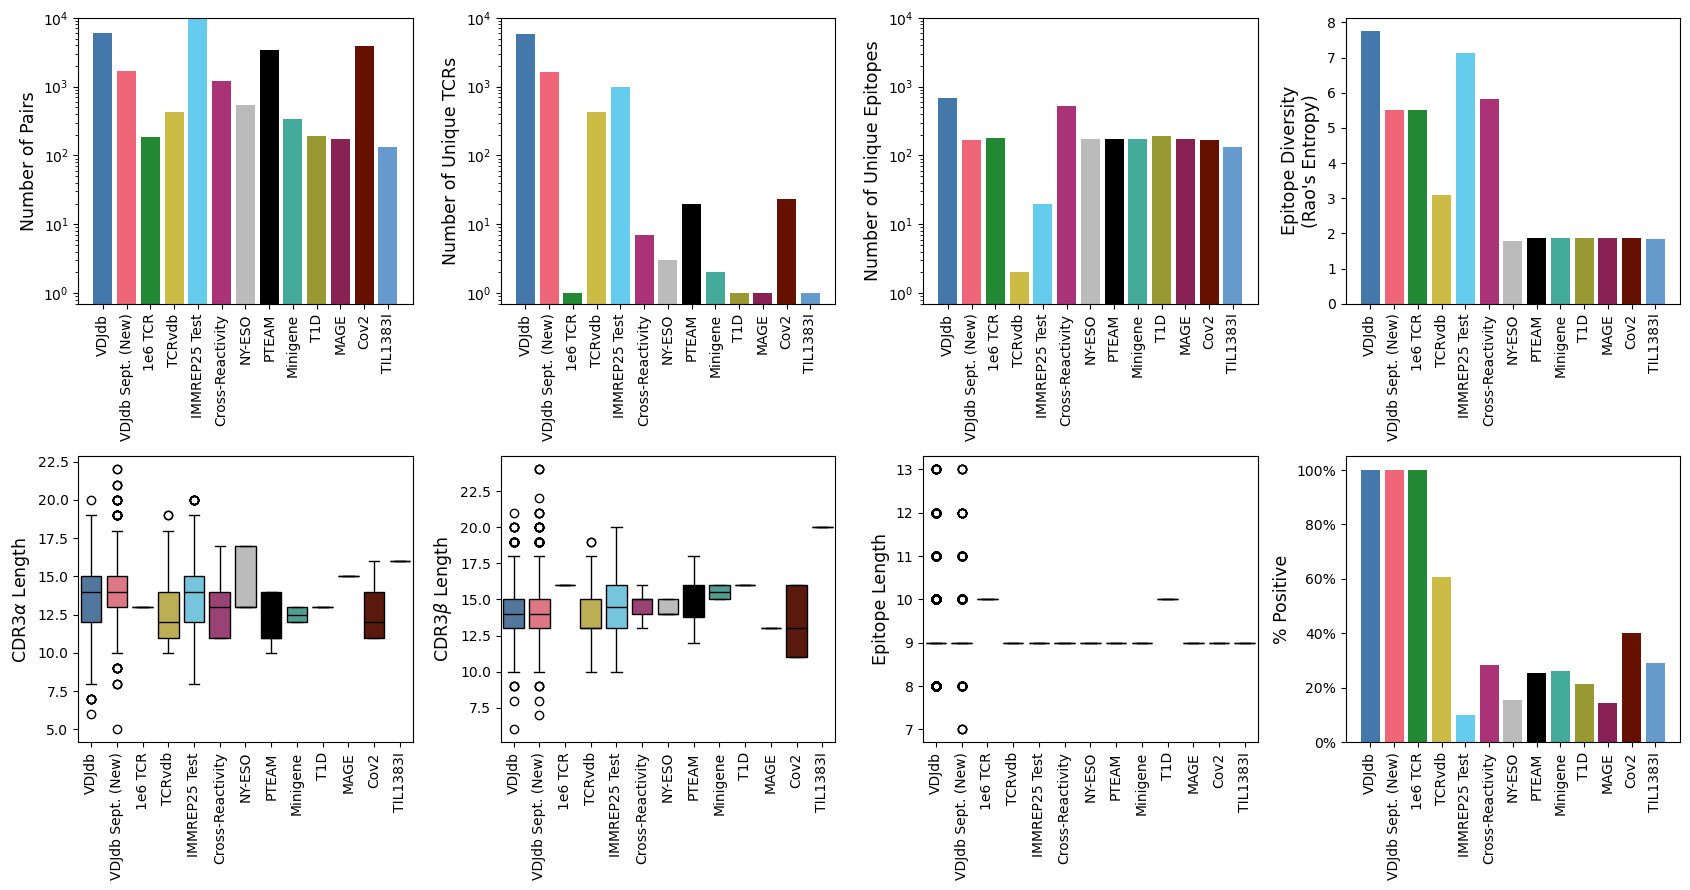

In [9]:
labelfontsize=12.5
import matplotlib.ticker as mtick
tab_colors = [
    "#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE",
    "#AA3377", "#BBBBBB", "#000000", "#44AA99", "#999933",
    "#882255", "#661100", "#6699CC", "#DDCC77"
]

fig, axes = plt.subplots(figsize=(17,9),ncols=4,nrows=2)

ax = axes[0,0]
y1 = [x.shape[0] for x in datasets.values()]
ax.bar(datasets.keys(), y1,color=tab_colors)
ax.set_yscale('log')
ax.set_ylabel('Number of Pairs',fontsize=labelfontsize)
ax.set_ylim([0.7,1e4])


ax = axes[0,1]
y2 = [len(x.cdr3_both.unique()) for x in datasets.values()]
ax.bar(datasets.keys(), y2,color=tab_colors)
ax.set_ylabel('Number of Unique TCRs',fontsize=labelfontsize)
ax.set_yscale('log')
ax.set_ylim([0.7,1e4])

ax = axes[0,2]
y2 = [len(x.peptide.unique()) for x in datasets.values()]
ax.bar(datasets.keys(), y2,color=tab_colors)
ax.set_ylabel('Number of Unique Epitopes',fontsize=labelfontsize)
ax.set_yscale('log')
ax.set_ylim([0.7,1e4])

ax = axes[0,3]
ye = [entropies[x] for x in datasets]
ax.bar(datasets.keys(), ye,color=tab_colors)
ax.set_ylabel("Epitope Diversity\n(Rao's Entropy)",fontsize=labelfontsize,labelpad=5)
ax = axes[1,3]
y3 = [positive_pct[x] for x in datasets]
ax.bar(datasets.keys(), y3,color=tab_colors)
ax.set_ylabel('% Positive',fontsize=labelfontsize)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

ax = axes[1,0]
sns.boxplot(all_validation_data,x='dataset',y='cdr3a_L',ax=ax,hue='dataset',palette=tab_colors)
ax.set_ylabel(r'CDR3$\alpha$ Length',fontsize=labelfontsize)
ax.set_xlabel('')

ax = axes[1,1]
sns.boxplot(all_validation_data,x='dataset',y='cdr3b_L',ax=ax,hue='dataset',palette=tab_colors)
ax.set_ylabel(r'CDR3$\beta$ Length',fontsize=labelfontsize)
ax.set_xlabel('')
ax = axes[1,2]
sns.boxplot(all_validation_data,x='dataset',y='epitope_L',ax=ax,hue='dataset',palette=tab_colors)
ax.set_ylabel('Epitope Length',fontsize=labelfontsize)
ax.set_xlabel('')




for ax in axes.reshape(-1):
    ax.tick_params(axis='x', rotation=90) 


fig.tight_layout()
fig.savefig('all_data_comparisons_human.png',bbox_inches='tight')
fig.savefig('all_data_comparisons_human.svg',bbox_inches='tight')


In [10]:
counts = (
    all_validation_data
    .groupby(['dataset', 'HLA'])
    .size()
    .reset_index(name='count')
)

counts['percent'] = (
    counts['count'] /
    counts.groupby('dataset')['count'].transform('sum') * 100
)

def get_locus(hla):
    if 'HLA-A' in hla:
        return 'A'
    elif 'HLA-B' in hla:
        return 'B'
    elif 'HLA-C' in hla:
        return 'C'
    else:
        return 'Other'

counts['locus'] = counts['HLA'].apply(get_locus)
plot_df = counts.pivot(
    index='HLA',
    columns='dataset',
    values='percent'
).fillna(0)

plot_df = plot_df.reindex(columns=list(datasets.keys()))
allele_abundance = (
    counts.groupby(['locus', 'HLA'])['percent']
    .mean()
    .reset_index()
)

allele_order = (
    allele_abundance
    .sort_values(['locus', 'percent'], ascending=[True, False])
    .groupby('locus', sort=False)['HLA']
    .apply(list)
    .sum()
)
plot_df = plot_df.reindex(allele_order)
plot_df = plot_df.replace(0, np.nan)
plot_log = np.log10(plot_df)

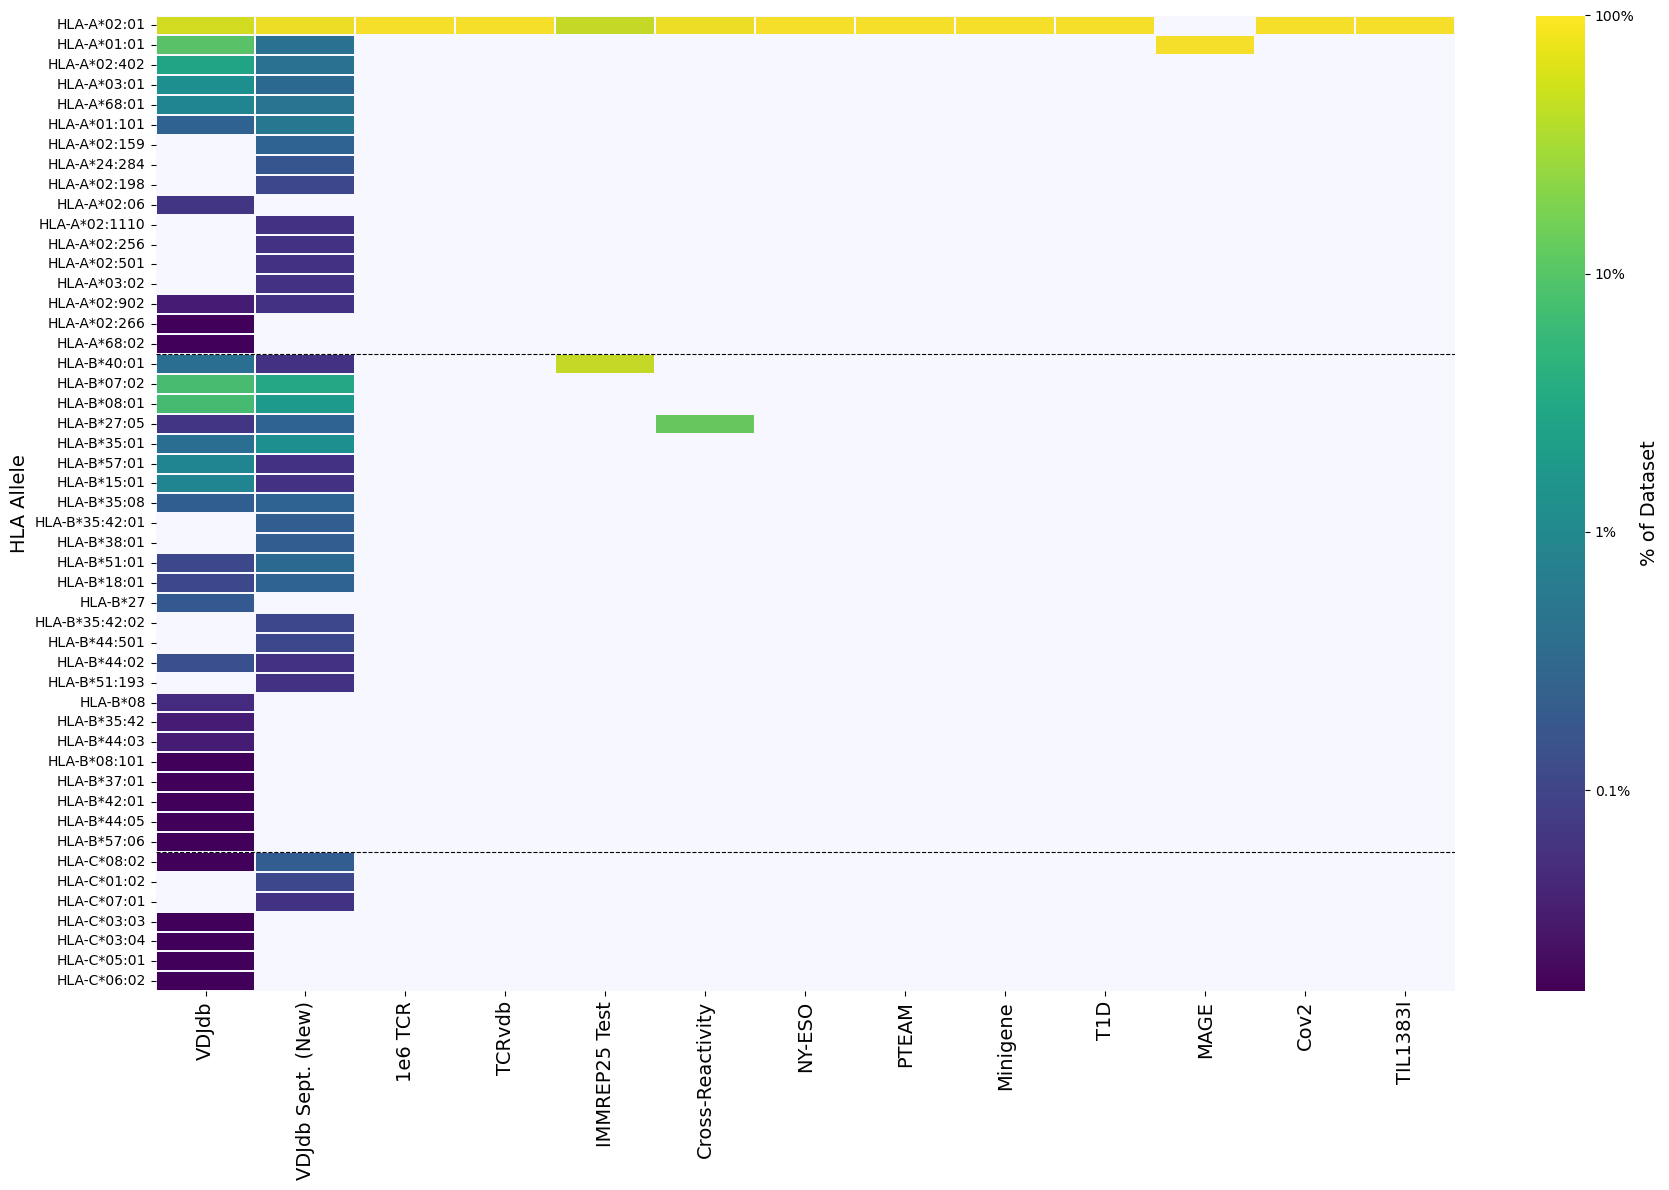

In [11]:
fig,ax= plt.subplots(figsize=(18, 12))

labelfontsize=14

sns.heatmap(
    plot_log,
    cmap='viridis',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'log10 Percent of Dataset'},
    yticklabels=plot_log.index,
    ax=ax
)

ax.set_xlabel('')
ax.set_ylabel('HLA Allele',fontsize=labelfontsize)

a_end = len([x for x in plot_df.index if 'HLA-A' in x])
b_end = a_end + len([x for x in plot_df.index if 'HLA-B' in x])
ax.axhline(a_end, color='black', linewidth=.8,linestyle='dashed')
ax.axhline(b_end, color='black', linewidth=.8,linestyle='dashed')
ax.axhspan(0, a_end, facecolor='blue', alpha=0.03)
ax.axhspan(a_end, b_end, facecolor='blue', alpha=0.03)
ax.axhspan(b_end, len(plot_df), facecolor='blue', alpha=0.03)

ax.tick_params(axis='x', labelsize=labelfontsize) 

cbar = ax.collections[0].colorbar
tick_locs = [-1, 0, 1,2]

tick_labels = ['0.1%', '1%', '10%', '100%']

cbar.set_ticks(tick_locs)
cbar.set_ticklabels(tick_labels)

cbar.set_label('% of Dataset', fontsize=labelfontsize)


fig.tight_layout()
fig.savefig('all_datasets_hla_heatmap.png')
fig.savefig('all_datasets_hla_heatmap.svg')

In [12]:
[x.shape[0] for x in datasets.values()]

[6016, 1681, 185, 427, 10000, 1204, 540, 3440, 344, 191, 172, 3910, 134]

In [13]:
plot_df

dataset,VDJdb,VDJdb Sept. (New),1e6 TCR,TCRvdb,IMMREP25 Test,Cross-Reactivity,NY-ESO,PTEAM,Minigene,T1D,MAGE,Cov2,TIL1383I
HLA,,,,,,,,,,,,,
HLA-A*02:01,61.951463,86.555622,100.0,100.0,50.0,85.714286,100.0,100.0,100.0,100.0,NaN,100.0,100.0
HLA-A*01:01,11.053856,0.475907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NaN,NaN
HLA-A*02:402,3.125000,0.475907,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-A*03:01,1.479388,0.356930,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-A*68:01,1.047207,0.535396,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-A*01:101,0.282580,0.594884,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-A*02:159,NaN,0.297442,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-A*24:284,NaN,0.178465,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HLA-A*02:198,NaN,0.118977,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
